# CREAM Graph Sanity Checks

This notebook loads the original/all-ones/identity/random graph sanity runs, CUB progressive-noise runs, intervention curves, and CUB ER-randomness statistics.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 160)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'experiments').exists() and (PROJECT_ROOT.parent / 'experiments').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

dataset_roots = {
    'celeba': PROJECT_ROOT / 'experiments/CelebA/train_cbm/Standard_CelebA/celeba_graph_sanity/CREAM_celeba_graph_sanity',
    'cub': PROJECT_ROOT / 'experiments/CUB/train_cbm/Standard_CUB/cub_graph_sanity/CREAM_cub_graph_sanity',
    'cfmnist': PROJECT_ROOT / 'experiments/Complete_Concept_FMNIST/train_cbm/Standard_FashionMNIST/cfmnist_graph_sanity/CREAM_cfmnist_graph_sanity',
}

variant_order = ['original', 'all_ones', 'identity', 'random_same_edges']
progressive_root = PROJECT_ROOT / 'experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise'
progressive_metadata_path = PROJECT_ROOT / 'data/CUB/progressive_noise_graph/progressive_noise_metadata.csv'
er_root = PROJECT_ROOT / 'experiments/CUB/graph_randomness_er'

def read_first_row_csv(csv_path):
    df = pd.read_csv(csv_path)
    if df.empty:
        return None
    row = df.iloc[0].to_dict()
    row['csv_path'] = str(csv_path)
    return row

def load_last_metrics(root_map):
    rows = []
    for dataset, root in root_map.items():
        for csv_path in sorted(root.glob('*/last_metrics/*.csv')):
            row = read_first_row_csv(csv_path)
            if row is None:
                continue
            row['dataset'] = dataset
            row['variant'] = csv_path.relative_to(root).parts[0]
            rows.append(row)
    return pd.DataFrame(rows)

def load_interventions(root_map):
    rows = []
    for dataset, root in root_map.items():
        for csv_path in sorted(root.glob('*/lightning_logs/**/intervention_results.csv')):
            df = pd.read_csv(csv_path)
            if df.empty:
                continue
            df['dataset'] = dataset
            df['variant'] = csv_path.relative_to(root).parts[0]
            df['csv_path'] = str(csv_path)
            rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

def metric_columns(df):
    preferred = [
        'dataset', 'variant', 'noise_percent', 'graph_distance',
        'test_task_accuracy', 'test_concept_accuracy', 'test_dropout_task_accuracy',
        'CCI', 'PFI_concept_importance', 'PFI_side_importance',
        'num_trainable_parameters', 'csv_path',
    ]
    return [col for col in preferred if col in df.columns]

def intervention_accuracy_column(df):
    for col in ['test_task_accuracy', 'task_accuracy', 'accuracy', 'test_acc']:
        if col in df.columns:
            return col
    matches = [col for col in df.columns if 'accuracy' in col.lower() or col.lower().endswith('_acc')]
    return matches[0] if matches else None

def display_or_message(df, message, columns=None):
    if df.empty:
        print(message)
        return df
    return df[columns] if columns else df


## Graph Sanity Result Table

In [ ]:
sanity_results = load_last_metrics(dataset_roots)
if not sanity_results.empty:
    sanity_results['variant'] = pd.Categorical(sanity_results['variant'], categories=variant_order, ordered=True)
    sanity_results = sanity_results.sort_values(['dataset', 'variant'])

display_or_message(
    sanity_results,
    'No graph sanity last_metrics CSVs found yet. Run the graph_sanity Condor jobs first.',
    metric_columns(sanity_results),
)


,dataset,variant,test_task_accuracy,test_concept_accuracy,test_dropout_task_accuracy,CCI,PFI_concept_importance,PFI_side_importance,num_trainable_parameters,csv_path
2,celeba,original,0.816251,0.810454,0.816350,1.0,3.164973e-01,-1.597459e-08,38597,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_graph_sanity/CREAM_celeba_graph_sanity/original/last_metrics/CREAM_celeba_graph_s...
0,celeba,all_ones,0.816451,0.806339,0.816452,1.0,3.163425e-01,-5.882233e-09,38987,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_graph_sanity/CREAM_celeba_graph_sanity/all_ones/last_metrics/CREAM_celeba_graph_s...
1,celeba,identity,0.499699,0.805888,0.500051,NaN,1.466378e-08,1.466378e-08,38560,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_graph_sanity/CREAM_celeba_graph_sanity/identity/last_metrics/CREAM_celeba_graph_s...


## Graph Sanity Accuracy

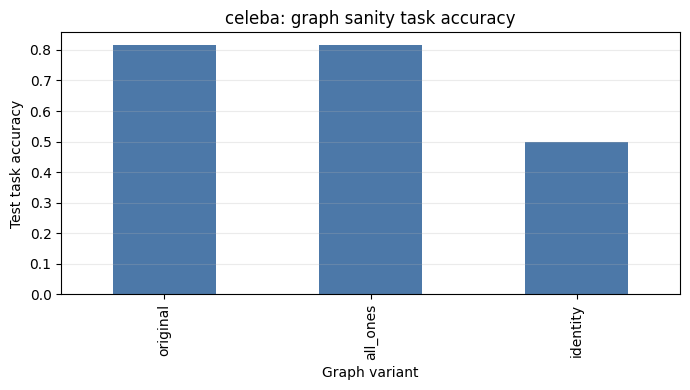

In [3]:
if sanity_results.empty or 'test_task_accuracy' not in sanity_results.columns:
    print('No test_task_accuracy values available yet.')
else:
    for dataset, df in sanity_results.groupby('dataset', observed=False):
        df = df.dropna(subset=['test_task_accuracy']).sort_values('variant')
        if df.empty:
            continue
        ax = df.plot.bar(x='variant', y='test_task_accuracy', legend=False, figsize=(7, 4), color='#4c78a8')
        ax.set_title(f'{dataset}: graph sanity task accuracy')
        ax.set_xlabel('Graph variant')
        ax.set_ylabel('Test task accuracy')
        ax.grid(axis='y', alpha=0.25)
        plt.tight_layout()
        plt.show()


## Graph Sanity Intervention Curves

In [4]:
sanity_interventions = load_interventions(dataset_roots)
display_or_message(
    sanity_interventions,
    'No graph sanity intervention_results.csv files found yet.',
    [c for c in ['dataset', 'variant', 'group_interventions', 'num_interventions', intervention_accuracy_column(sanity_interventions), 'csv_path'] if c and c in sanity_interventions.columns],
)


,dataset,variant,group_interventions,num_interventions,test_task_accuracy,csv_path
0,celeba,all_ones,False,0.0,0.816451,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_graph_sanity/CREAM_celeba_graph_sanity/all_ones/lightning_logs/version_0/interven...
1,celeba,all_ones,False,1.0,0.809087,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_graph_sanity/CREAM_celeba_graph_sanity/all_ones/lightning_logs/version_0/interven...
2,celeba,all_ones,False,2.0,0.807134,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_graph_sanity/CREAM_celeba_graph_sanity/all_ones/lightning_logs/version_0/interven...
3,celeba,all_ones,False,3.0,0.814698,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_graph_sanity/CREAM_celeba_graph_sanity/all_ones/lightning_logs/version_0/interven...
4,celeba,all_ones,False,4.0,0.813546,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_graph_sanity/CREAM_celeba_graph_sanity/all_ones/lightning_logs/version_0/interven...
5,celeba,all_ones,False,5.0,0.814347,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_graph_sanity/CREAM_celeba_graph_sanity/all_ones/lightning_logs/version_0/interven...
6,celeba,all_ones,False,6.0,0.817403,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_graph_sanity/CREAM_celeba_graph_sanity/all_ones/lightning_logs/version_0/interven...
7,celeba,all_ones,False,7.0,0.827021,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_graph_sanity/CREAM_celeba_graph_sanity/all_ones/lightning_logs/version_0/interven...
8,celeba,identity,False,0.0,0.499699,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_graph_sanity/CREAM_celeba_graph_sanity/identity/lightning_logs/version_0/interven...
9,celeba,identity,False,1.0,0.499699,/home/dani00003/mCREAM/experiments/CelebA/train_cbm/Standard_CelebA/celeba_graph_sanity/CREAM_celeba_graph_sanity/identity/lightning_logs/version_0/interven...


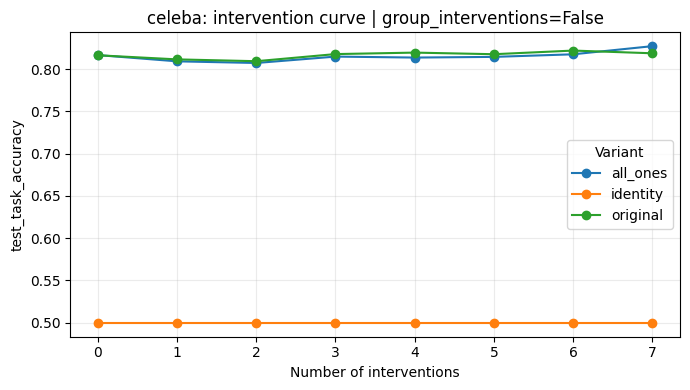

In [5]:
acc_col = intervention_accuracy_column(sanity_interventions)
if sanity_interventions.empty or acc_col is None or 'num_interventions' not in sanity_interventions.columns:
    print('No plottable graph sanity intervention curves yet.')
else:
    for dataset, dataset_df in sanity_interventions.groupby('dataset'):
        group_values = [None]
        if 'group_interventions' in dataset_df.columns:
            group_values = sorted(dataset_df['group_interventions'].dropna().unique())
        for group_value in group_values:
            df = dataset_df if group_value is None else dataset_df[dataset_df['group_interventions'] == group_value]
            if df.empty:
                continue
            fig, ax = plt.subplots(figsize=(7, 4))
            for variant, variant_df in df.groupby('variant'):
                variant_df = variant_df.sort_values('num_interventions')
                ax.plot(variant_df['num_interventions'], variant_df[acc_col], marker='o', label=str(variant))
            suffix = '' if group_value is None else f' | group_interventions={group_value}'
            ax.set_title(f'{dataset}: intervention curve{suffix}')
            ax.set_xlabel('Number of interventions')
            ax.set_ylabel(acc_col)
            ax.grid(alpha=0.25)
            ax.legend(title='Variant')
            plt.tight_layout()
            plt.show()


## CUB Progressive Noise Result Table

In [6]:
progressive_results = load_last_metrics({'cub': progressive_root})
if not progressive_results.empty:
    progressive_results = progressive_results.rename(columns={'variant': 'noise_variant'})
    progressive_results['noise_percent'] = progressive_results['noise_variant'].str.extract(r'(\d+)').astype(float)
    progressive_results['noise_percent'] = progressive_results['noise_percent'].where(progressive_results['noise_percent'] > 1, progressive_results['noise_percent'] * 100)
    progressive_results['noise_percent'] = progressive_results['noise_percent'].astype('Int64')
    if progressive_metadata_path.exists():
        progressive_metadata = pd.read_csv(progressive_metadata_path)
        progressive_results = progressive_results.merge(progressive_metadata, on='noise_percent', how='left', suffixes=('', '_metadata'))
    elif 'graph_distance' not in progressive_results.columns:
        progressive_results['graph_distance'] = progressive_results['noise_percent'] / 100.0
    progressive_results = progressive_results.sort_values('noise_percent')

display_or_message(
    progressive_results,
    'No CUB progressive-noise last_metrics CSVs found yet. Run the progressive_noise Condor jobs first.',
    [c for c in ['noise_variant', 'noise_percent', 'graph_distance', 'num_flipped_positions', 'original_true_entries', 'perturbed_true_entries', 'test_task_accuracy', 'test_concept_accuracy', 'CCI', 'PFI_concept_importance', 'PFI_side_importance', 'csv_path'] if c in progressive_results.columns],
)


,noise_variant,noise_percent,graph_distance,test_task_accuracy,test_concept_accuracy,PFI_concept_importance,PFI_side_importance,csv_path
0,noise_010,10,0.099996,0.729375,0.868315,6.953815e-01,0.014468,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_010/last_metrics/CREAM_cub_progressive...
1,noise_020,20,0.200002,0.730929,0.868013,6.925820e-01,0.018050,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_020/last_metrics/CREAM_cub_progressive...
2,noise_030,30,0.299998,0.731964,0.866814,6.894477e-01,0.016705,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_030/last_metrics/CREAM_cub_progressive...
3,noise_040,40,0.400004,0.730411,0.866444,6.840542e-01,0.020718,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_040/last_metrics/CREAM_cub_progressive...
4,noise_050,50,0.500000,0.729030,0.864121,6.721091e-01,0.026372,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_050/last_metrics/CREAM_cub_progressive...
5,noise_060,60,0.599996,0.729720,0.861795,6.615206e-01,0.040618,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_060/last_metrics/CREAM_cub_progressive...
6,noise_070,70,0.700002,0.728857,0.860137,6.306265e-01,0.068607,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_070/last_metrics/CREAM_cub_progressive...
7,noise_080,80,0.799998,0.710563,0.860128,5.384674e-01,0.146652,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_080/last_metrics/CREAM_cub_progressive...
8,noise_090,90,0.900004,0.696410,0.865988,3.479375e-01,0.396158,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_090/last_metrics/CREAM_cub_progressive...
9,noise_100,100,1.000000,0.717639,0.872174,-2.701446e-08,0.712466,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_100/last_metrics/CREAM_cub_progressive...


## CUB Progressive Noise Curves

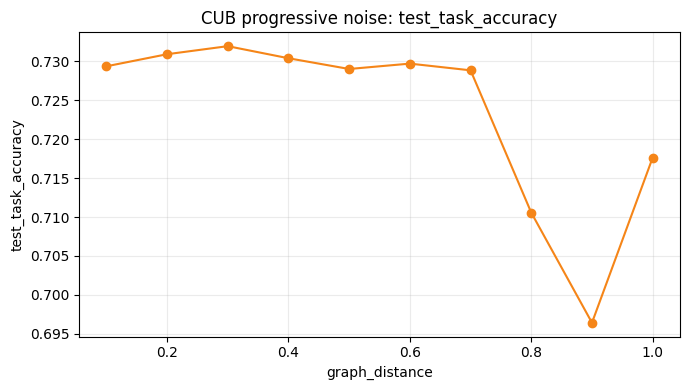

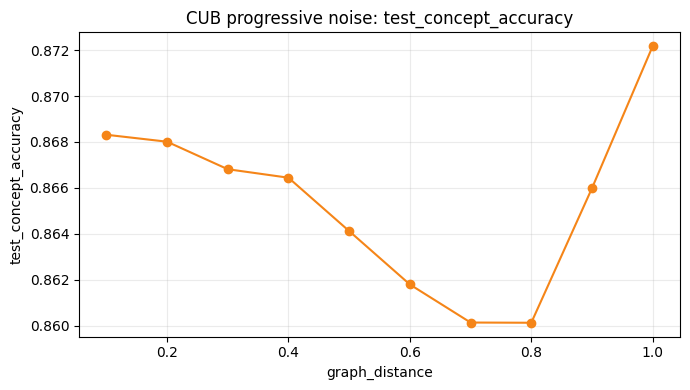

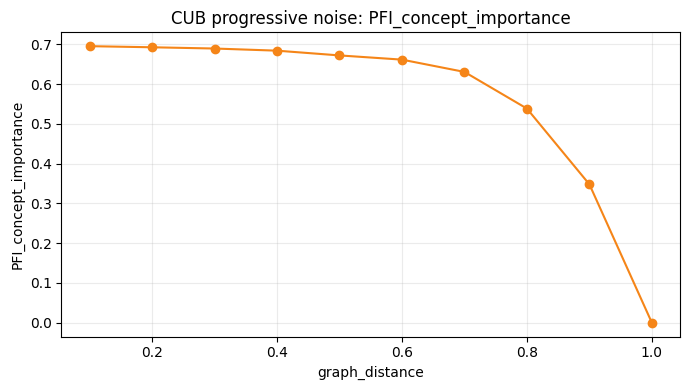

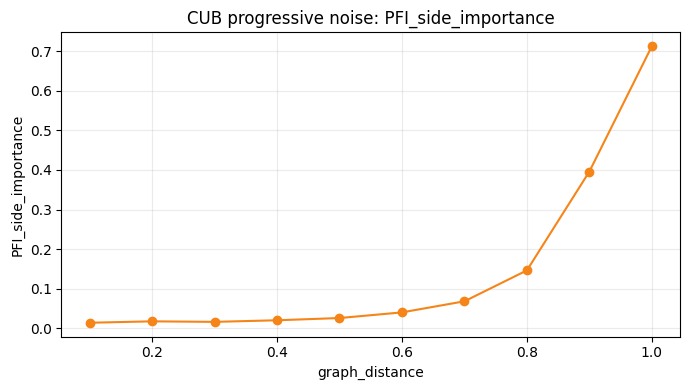

In [7]:
if progressive_results.empty:
    print('No CUB progressive-noise metrics available yet.')
else:
    x_col = 'graph_distance' if 'graph_distance' in progressive_results.columns else 'noise_percent'
    for y_col in ['test_task_accuracy', 'test_concept_accuracy', 'CCI', 'PFI_concept_importance', 'PFI_side_importance']:
        if y_col not in progressive_results.columns:
            continue
        df = progressive_results.dropna(subset=[x_col, y_col]).sort_values(x_col)
        if df.empty:
            continue
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(df[x_col], df[y_col], marker='o', color='#f58518')
        ax.set_title(f'CUB progressive noise: {y_col}')
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()


## CUB Progressive Noise Intervention Curves

In [8]:
progressive_interventions = load_interventions({'cub': progressive_root})
if not progressive_interventions.empty:
    progressive_interventions = progressive_interventions.rename(columns={'variant': 'noise_variant'})
    progressive_interventions['noise_percent'] = progressive_interventions['noise_variant'].str.extract(r'(\d+)').astype(float)
    progressive_interventions['noise_percent'] = progressive_interventions['noise_percent'].where(progressive_interventions['noise_percent'] > 1, progressive_interventions['noise_percent'] * 100)
    progressive_interventions['noise_percent'] = progressive_interventions['noise_percent'].astype('Int64')
    if progressive_metadata_path.exists():
        progressive_interventions = progressive_interventions.merge(pd.read_csv(progressive_metadata_path), on='noise_percent', how='left')

display_or_message(
    progressive_interventions,
    'No CUB progressive-noise intervention_results.csv files found yet.',
    [c for c in ['noise_variant', 'noise_percent', 'graph_distance', 'group_interventions', 'num_interventions', intervention_accuracy_column(progressive_interventions), 'csv_path'] if c and c in progressive_interventions.columns],
)


,noise_variant,noise_percent,graph_distance,group_interventions,num_interventions,test_task_accuracy,csv_path
0,noise_010,10,0.099996,True,0.0,0.729375,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_010/lightning_logs/version_0/intervent...
1,noise_010,10,0.099996,True,1.0,0.740766,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_010/lightning_logs/version_0/intervent...
2,noise_010,10,0.099996,True,2.0,0.751467,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_010/lightning_logs/version_0/intervent...
3,noise_010,10,0.099996,True,3.0,0.761305,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_010/lightning_logs/version_0/intervent...
4,noise_010,10,0.099996,True,4.0,0.774594,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_010/lightning_logs/version_0/intervent...
...,...,...,...,...,...,...,...
1385,noise_100,100,1.000000,False,108.0,0.717639,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_100/lightning_logs/version_0/intervent...
1386,noise_100,100,1.000000,False,109.0,0.717639,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_100/lightning_logs/version_0/intervent...
1387,noise_100,100,1.000000,False,110.0,0.717639,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_100/lightning_logs/version_0/intervent...
1388,noise_100,100,1.000000,False,111.0,0.717639,/home/dani00003/mCREAM/experiments/CUB/train_cbm/Standard_CUB/cub_progressive_noise/CREAM_cub_progressive_noise/noise_100/lightning_logs/version_0/intervent...


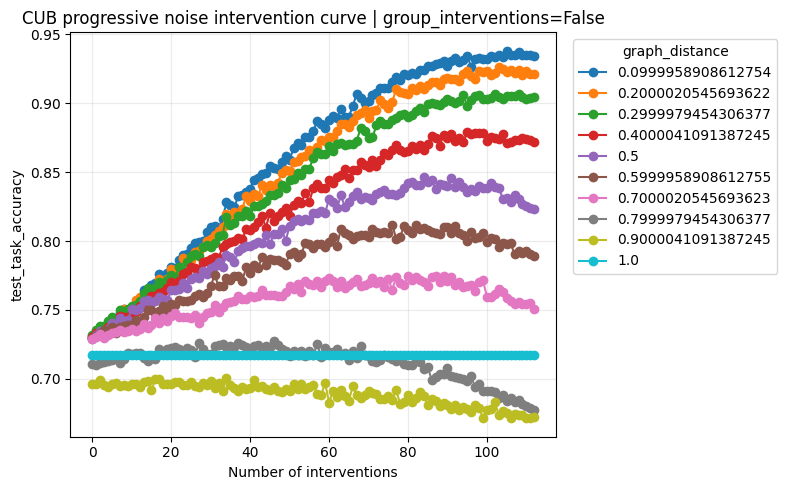

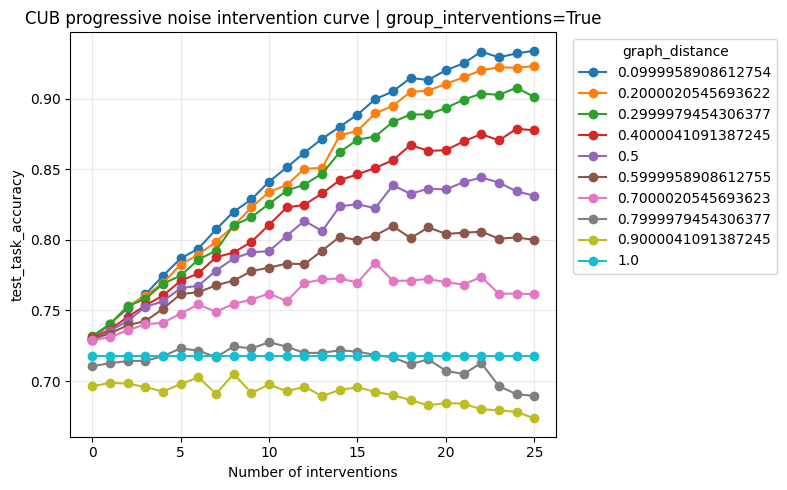

In [9]:
acc_col = intervention_accuracy_column(progressive_interventions)
if progressive_interventions.empty or acc_col is None or 'num_interventions' not in progressive_interventions.columns:
    print('No plottable CUB progressive-noise intervention curves yet.')
else:
    group_values = [None]
    if 'group_interventions' in progressive_interventions.columns:
        group_values = sorted(progressive_interventions['group_interventions'].dropna().unique())
    for group_value in group_values:
        df = progressive_interventions if group_value is None else progressive_interventions[progressive_interventions['group_interventions'] == group_value]
        if df.empty:
            continue
        fig, ax = plt.subplots(figsize=(8, 5))
        hue_col = 'graph_distance' if 'graph_distance' in df.columns else 'noise_percent'
        for hue_value, hue_df in df.groupby(hue_col):
            hue_df = hue_df.sort_values('num_interventions')
            ax.plot(hue_df['num_interventions'], hue_df[acc_col], marker='o', label=str(hue_value))
        suffix = '' if group_value is None else f' | group_interventions={group_value}'
        ax.set_title(f'CUB progressive noise intervention curve{suffix}')
        ax.set_xlabel('Number of interventions')
        ax.set_ylabel(acc_col)
        ax.grid(alpha=0.25)
        ax.legend(title=hue_col, bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.show()


## CUB ER Randomness Results

In [10]:
z_path = er_root / 'z_scores.csv'
original_path = er_root / 'original_metrics.csv'
ensemble_path = er_root / 'er_ensemble_metrics.csv'
metadata_path = er_root / 'metadata.json'

er_z = pd.read_csv(z_path) if z_path.exists() else pd.DataFrame()
er_original = pd.read_csv(original_path) if original_path.exists() else pd.DataFrame()
er_ensemble = pd.read_csv(ensemble_path) if ensemble_path.exists() else pd.DataFrame()
er_metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}

if er_metadata:
    print(json.dumps(er_metadata, indent=2))

display_or_message(er_z, 'No ER-randomness z_scores.csv found yet. Run the CUB ER randomness job first.')


{
  "dag": "data/CUB/CUB_DAG_only_Gc.csv",
  "n_nodes": 312,
  "n_edges": 26088,
  "er_p": 0.5377195152114767,
  "n_graphs": 100,
  "seed": 42,
  "graph_model": "Uniform undirected fixed-edge graph G(n, m), equivalent to ER baseline with matched edge count",
  "preprocessing": "symmetrized adjacency with diagonal removed"
}


,metric,original,er_mean,er_std,z_score
0,average_degree,167.230769,167.230769,2.856489e-14,-0.994987
1,degree_variance,5820.478797,76.147194,6.225693e+00,922.681466
2,clustering_coefficient,0.524881,0.537693,3.042008e-04,-42.117104
3,num_triangles,175.666667,-90.753333,2.060148e+02,1.293208
4,largest_eigenvalue,190.068036,167.684804,3.704307e-02,604.248850
5,spectral_gap,163.777589,150.984068,2.261842e-01,56.562392


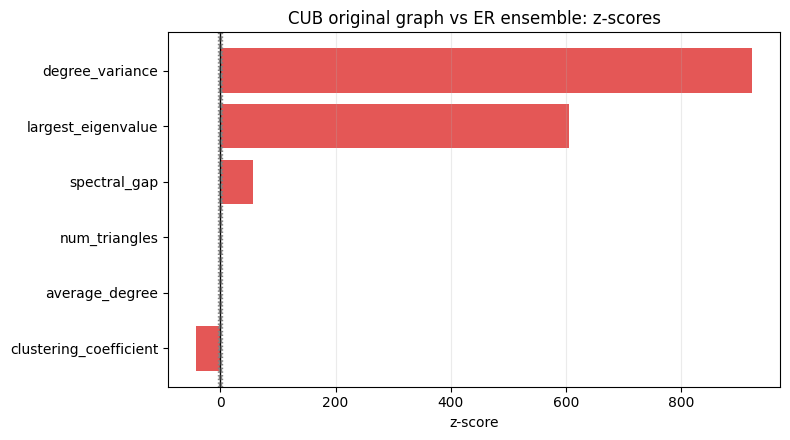

In [11]:
if er_z.empty:
    print('No ER z-score plot available yet.')
else:
    metric_col = 'metric' if 'metric' in er_z.columns else er_z.columns[0]
    z_col = 'z_score' if 'z_score' in er_z.columns else [c for c in er_z.columns if 'z' in c.lower()][0]
    plot_df = er_z.sort_values(z_col)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    colors = np.where(plot_df[z_col].abs() >= 3, '#e45756', np.where(plot_df[z_col].abs() >= 2, '#f58518', '#4c78a8'))
    ax.barh(plot_df[metric_col], plot_df[z_col], color=colors)
    ax.axvline(0, color='black', linewidth=1)
    ax.axvline(2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(-2, color='gray', linestyle='--', linewidth=1)
    ax.axvline(3, color='gray', linestyle=':', linewidth=1)
    ax.axvline(-3, color='gray', linestyle=':', linewidth=1)
    ax.set_title('CUB original graph vs ER ensemble: z-scores')
    ax.set_xlabel('z-score')
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()


In [12]:
if er_original.empty or er_ensemble.empty:
    print('No ER original/ensemble metric tables available yet.')
else:
    print('Original CUB graph metrics')
    display(er_original)
    print('ER ensemble summary')
    display(er_ensemble.describe().T[['mean', 'std', 'min', 'max']])


Original CUB graph metrics


,average_degree,degree_variance,clustering_coefficient,num_triangles,largest_eigenvalue,spectral_gap,n_nodes,n_edges,er_p
0,167.230769,5820.478797,0.524881,175.666667,190.068036,163.777589,312,26088,0.53772


ER ensemble summary


,mean,std,min,max
average_degree,167.230769,2.856489e-14,167.230769,167.230769
degree_variance,76.147194,6.225693e+00,62.222387,91.690335
clustering_coefficient,0.537693,3.042008e-04,0.537115,0.538443
num_triangles,-90.753333,2.060148e+02,-682.333333,409.000000
largest_eigenvalue,167.684804,3.704307e-02,167.603154,167.774384
spectral_gap,150.984068,2.261842e-01,150.315901,151.453551
graph_idx,49.500000,2.901149e+01,0.000000,99.000000
n_nodes,312.000000,0.000000e+00,312.000000,312.000000
n_edges,26088.000000,0.000000e+00,26088.000000,26088.000000
